In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator


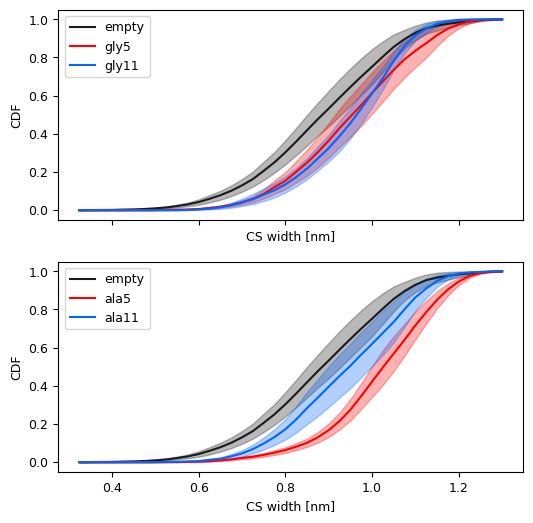

In [42]:
plt.rcParams.update({"font.size": 9})

SYSTEMS = [["empty","gly5", "gly11"],
           ["empty","ala5", "ala11"]]

COLORS = {
    "empty": "#1a1a1a",
    "gly5": "#ff0000",
    "gly11": "#0066ff",
    "ala5": "#ff0000",
    "ala11": "#0066ff",
}

def getPlottingData(mol, width_range, bins):

    # initialize containers
    widths = []
    cdfs = []

    # read data from all trajectories
    for tid in range(8):

        # read file
        fname_w = f"../output_files/cs_width/{mol.lower()}.{tid}.dat"
        data_w = np.loadtxt(fname_w)
        
        # take only latter portions
        widths = data_w[:, 1] / 10
        
        # get histogram
        H, edges = np.histogram(widths,
                                bins=bins, range=width_range,
                                density=True)
        
        # get cummulative sum
        dx = edges[1] - edges[0]
        cdf = np.cumsum(H) * dx
        cdfs.append(cdf)
        
    mean = np.mean(cdfs, axis=0)
    std = np.std(cdfs, axis=0) / 8**0.5
    upper = mean+std
    lower = mean-std

    return edges, mean, std, upper, lower

# some setup
width_range = [0.3, 1.3] # 1.1
bins = 40

# initialize figure
fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True, sharey=True,
                        figsize=(6,6))
                                 
for row, mols in enumerate(SYSTEMS):
    
    ax = axs[row]
    
    for mol in mols:
    
        edges, mean, std, upper, lower = getPlottingData(mol, width_range, bins)
        
        ax.plot(edges[1:], mean, color=COLORS[mol], label=mol)
        ax.fill_between(edges[1:], lower, upper, color=COLORS[mol], alpha=0.3)
    
    ax.legend()
    ax.set_xlabel("CS width [nm]")
    ax.set_ylabel("CDF")
        